In [ ]:
#!/usr/bin/env python3
"""
Comprehensive Topology Test: All Topologies on All Tasks (2-Layer Networks)

This script tests ALL topology types on ALL tasks using ALL three versions with 2-layer networks:

Topologies:
- Fully Connected
- Small World  
- Modular
- Hybrid

Tasks:
- CartPole-v1
- MountainCar-v0
- Acrobot-v1

Versions:
- Version A: Minimal Task Adapters (Universal approach)
- Version B: IO Padding/Truncation (Universal approach)  
- Version C: Single Task Direct (Simple approach)
- Standard MLP (Baseline comparison)

Total: 4 topologies × 3 tasks × 4 versions = 48 experiments
All using 2-layer topology networks
"""

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import sys
import os
import time
from typing import Dict, List, Tuple, Any

# Add src to path
sys.path.append('src')

from src.topologies.fully_connected import FullyConnectedTopology
from src.topologies.small_world import SmallWorldTopology
from src.topologies.modular import ModularTopology
from src.topologies.hybrid import HybridTopology
from src.networks.ffn import FeedForwardNetwork 

class TrainingCallback(BaseCallback):
    """Callback to track training metrics."""
    
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.current_episode_reward = 0
        self.current_episode_length = 0
        
    def _on_step(self) -> bool:
        # Track episode rewards
        if len(self.training_env.buf_rews) > 0:
            self.current_episode_reward += self.training_env.buf_rews[0]
            self.current_episode_length += 1
            
            if self.training_env.buf_dones[0]:
                self.episode_rewards.append(self.current_episode_reward)
                self.episode_lengths.append(self.current_episode_length)
                self.current_episode_reward = 0
                self.current_episode_length = 0
        
        return True

class StandardMLPPolicy(ActorCriticPolicy):
    """Standard 2-layer MLP policy for comparison."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # 2-layer architecture matching the topology networks
        self.shared_net = nn.Sequential(
            nn.Linear(self.features_dim, 64),  # Input → 64
            nn.ReLU(),
            nn.Linear(64, 64),                 # 64 → 64
            nn.ReLU(),
            nn.Linear(64, 64),                 # 64 → 64 (second layer)
            nn.ReLU(),
        )
        
        # Actor head (policy)
        self.action_net = nn.Sequential(
            nn.Linear(64, 32),                 # 64 → 32
            nn.ReLU(),
            nn.Linear(32, action_space.n)      # 32 → action_dim
        )
        
        # Critic head (value)
        self.value_net = nn.Sequential(
            nn.Linear(64, 32),                 # 64 → 32
            nn.ReLU(),
            nn.Linear(32, 1)                   # 32 → 1
        )
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        shared_features = self.shared_net(features)
        return self.action_net(shared_features)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        shared_features = self.shared_net(features)
        return self.value_net(shared_features) 

# ============================================================================
# VERSION A: Minimal Task Adapters (Universal approach) - 2 LAYERS
# ============================================================================

class MinimalAdapter(nn.Module):
    """Minimal adapter with configurable complexity."""
    
    def __init__(self, input_dim: int, output_dim: int, adapter_type: str = 'linear'):
        super().__init__()
        self.adapter_type = adapter_type
        
        if adapter_type == 'linear':
            # Simple linear projection
            self.projection = nn.Linear(input_dim, output_dim)
        elif adapter_type == 'tiny_mlp':
            # Tiny MLP with minimal hidden layer
            self.projection = nn.Sequential(
                nn.Linear(input_dim, 8),
                nn.ReLU(),
                nn.Linear(8, output_dim)
            )
        else:
            raise ValueError(f"Unknown adapter type: {adapter_type}")
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.projection(x)

class VersionA_AdapterPolicy_2Layers(ActorCriticPolicy):
    """Version A: Universal topology with minimal task adapters (2-layer)."""
    
    def __init__(self, observation_space, action_space, lr_schedule, topology_type='fully_connected', *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Task-specific dimensions
        self.task_input_dim = observation_space.shape[0]
        self.task_output_dim = action_space.n if hasattr(action_space, 'n') else action_space.shape[0]
        
        # Universal dimensions (fixed across all tasks)
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        self.topology_type = topology_type
        
        print(f"[Version A 2L - {topology_type}] Task: {self.task_input_dim}→{self.task_output_dim}")
        print(f"[Version A 2L - {topology_type}] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        
        # Create minimal input adapter
        self.input_adapter = MinimalAdapter(
            self.task_input_dim, 
            self.universal_input_dim, 
            adapter_type='linear'
        )
        
        # Create 2-layer topology network
        self.topology_network = self._create_topology_network()
        
        # Create minimal output adapter
        self.output_adapter = MinimalAdapter(
            self.universal_output_dim, 
            self.task_output_dim, 
            adapter_type='linear'
        )
        
        # Actor head (policy)
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n if hasattr(action_space, 'n') else action_space.shape[0])
        )
        
        # Critic head (value)
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the 2-layer topology network with universal dimensions."""
        # Total nodes per layer: input + hidden + output
        layer_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        
        # Create 2-layer topology based on type
        if self.topology_type == 'fully_connected':
            topology = FullyConnectedTopology(
                size=layer_size,
                num_layers=2,  # 2 layers
                inter_layer_prob=1.0,
                intra_layer_prob=1.0,
                seed=42
            )
        elif self.topology_type == 'small_world':
            topology = SmallWorldTopology(
                size=layer_size,
                k=4,
                p=0.1,
                num_layers=2,  # 2 layers
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'modular':
            topology = ModularTopology(
                size=layer_size,
                num_modules=4,
                inter_module_prob=0.1,
                intra_module_prob=0.3,
                num_layers=2,  # 2 layers
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'hybrid':
            topology = HybridTopology(
                size=layer_size,
                num_modules=4,
                k=4,
                p=0.1,
                inter_module_prob=0.1,
                num_layers=2,  # 2 layers
                inter_layer_prob=0.1,
                seed=42
            )
        else:
            raise ValueError(f"Unknown topology type: {self.topology_type}")
        
        # Generate 2-layer graph
        graphs = topology.generate(2)  # Generate 2 layers
        
        # Define input/output nodes for each layer
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        
        # Create network parameters
        network_params = {
            'learning_rate': 0.001,
            'activation': 'tanh'
        }
        
        # Create 2-layer network
        self.layer1_network = FeedForwardNetwork(graphs[0], input_nodes, output_nodes, network_params)
        self.layer2_network = FeedForwardNetwork(graphs[1], input_nodes, output_nodes, network_params)
    
    def forward_actor(self, obs):
        """Forward pass for actor (policy)."""
        features = self.extract_features(obs)
        
        # Input adapter: project to universal input space
        universal_input = self.input_adapter(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Layer 1
        layer1_output = self.layer1_network.forward(input_dict)
        
        # Convert layer1 output to input for layer2
        layer2_input = {}
        for i in range(self.universal_input_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(features.shape[0])
            layer2_input[i] = val
        
        # Layer 2
        layer2_output = self.layer2_network.forward(layer2_input)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Output adapter: project to task output space
        task_output = self.output_adapter(universal_output)
        
        # Actor head
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        """Forward pass for critic (value)."""
        features = self.extract_features(obs)
        
        # Input adapter: project to universal input space
        universal_input = self.input_adapter(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Layer 1
        layer1_output = self.layer1_network.forward(input_dict)
        
        # Convert layer1 output to input for layer2
        layer2_input = {}
        for i in range(self.universal_input_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(features.shape[0])
            layer2_input[i] = val
        
        # Layer 2
        layer2_output = self.layer2_network.forward(layer2_input)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Output adapter: project to task output space
        task_output = self.output_adapter(universal_output)
        
        # Critic head
        return self.critic_head(task_output)

# ============================================================================
# VERSION B: IO Padding/Truncation (Universal approach) - 2 LAYERS
# ============================================================================

class VersionB_PaddingPolicy_2Layers(ActorCriticPolicy):
    """Version B: Universal topology with padding/truncation (2-layer)."""
    
    def __init__(self, observation_space, action_space, lr_schedule, topology_type='fully_connected', *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Task-specific dimensions
        self.task_input_dim = observation_space.shape[0]
        self.task_output_dim = action_space.n if hasattr(action_space, 'n') else action_space.shape[0]
        
        # Universal dimensions (fixed across all tasks)
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        self.topology_type = topology_type
        
        print(f"[Version B 2L - {topology_type}] Task: {self.task_input_dim}→{self.task_output_dim}")
        print(f"[Version B 2L - {topology_type}] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        
        # Create 2-layer topology network
        self.topology_network = self._create_topology_network()
        
        # Actor head (policy)
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n if hasattr(action_space, 'n') else action_space.shape[0])
        )
        
        # Critic head (value)
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the 2-layer topology network with universal dimensions."""
        # Total nodes per layer: input + hidden + output
        layer_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        
        # Create 2-layer topology based on type
        if self.topology_type == 'fully_connected':
            topology = FullyConnectedTopology(
                size=layer_size,
                num_layers=2,  # 2 layers
                inter_layer_prob=1.0,
                intra_layer_prob=1.0,
                seed=42
            )
        elif self.topology_type == 'small_world':
            topology = SmallWorldTopology(
                size=layer_size,
                k=4,
                p=0.1,
                num_layers=2,  # 2 layers
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'modular':
            topology = ModularTopology(
                size=layer_size,
                num_modules=4,
                inter_module_prob=0.1,
                intra_module_prob=0.3,
                num_layers=2,  # 2 layers
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'hybrid':
            topology = HybridTopology(
                size=layer_size,
                num_modules=4,
                k=4,
                p=0.1,
                inter_module_prob=0.1,
                num_layers=2,  # 2 layers
                inter_layer_prob=0.1,
                seed=42
            )
        else:
            raise ValueError(f"Unknown topology type: {self.topology_type}")
        
        # Generate 2-layer graph
        graphs = topology.generate(2)  # Generate 2 layers
        
        # Define input/output nodes for each layer
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        
        # Create network parameters
        network_params = {
            'learning_rate': 0.001,
            'activation': 'tanh'
        }
        
        # Create 2-layer network
        self.layer1_network = FeedForwardNetwork(graphs[0], input_nodes, output_nodes, network_params)
        self.layer2_network = FeedForwardNetwork(graphs[1], input_nodes, output_nodes, network_params)
    
    def _pad_input(self, x: torch.Tensor) -> torch.Tensor:
        """Pad input to universal input dimension."""
        if x.shape[1] < self.universal_input_dim:
            # Pad with zeros
            padding = torch.zeros(x.shape[0], self.universal_input_dim - x.shape[1], device=x.device)
            return torch.cat([x, padding], dim=1)
        else:
            # Truncate if too large
            return x[:, :self.universal_input_dim]
    
    def _truncate_output(self, x: torch.Tensor) -> torch.Tensor:
        """Truncate output to task output dimension."""
        return x[:, :self.task_output_dim]
    
    def forward_actor(self, obs):
        """Forward pass for actor (policy)."""
        features = self.extract_features(obs)
        
        # Pad input to universal input space
        universal_input = self._pad_input(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Layer 1
        layer1_output = self.layer1_network.forward(input_dict)
        
        # Convert layer1 output to input for layer2
        layer2_input = {}
        for i in range(self.universal_input_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(features.shape[0])
            layer2_input[i] = val
        
        # Layer 2
        layer2_output = self.layer2_network.forward(layer2_input)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Truncate output to task output space
        task_output = self._truncate_output(universal_output)
        
        # Actor head
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        """Forward pass for critic (value)."""
        features = self.extract_features(obs)
        
        # Pad input to universal input space
        universal_input = self._pad_input(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Layer 1
        layer1_output = self.layer1_network.forward(input_dict)
        
        # Convert layer1 output to input for layer2
        layer2_input = {}
        for i in range(self.universal_input_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(features.shape[0])
            layer2_input[i] = val
        
        # Layer 2
        layer2_output = self.layer2_network.forward(layer2_input)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Truncate output to task output space
        task_output = self._truncate_output(universal_output)
        
        # Critic head
        return self.critic_head(task_output)

# ============================================================================
# VERSION C: Single Task Direct (Simple approach) - 2 LAYERS
# ============================================================================

class VersionC_DirectPolicy_2Layers(ActorCriticPolicy):
    """Version C: Direct topology with task-specific dimensions (2-layer)."""
    
    def __init__(self, observation_space, action_space, lr_schedule, topology_type='fully_connected', *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Task-specific dimensions
        self.input_dim = observation_space.shape[0]
        self.output_dim = action_space.n if hasattr(action_space, 'n') else action_space.shape[0]
        self.hidden_size = 64
        self.topology_type = topology_type
        
        print(f"[Version C 2L - {topology_type}] Direct: {self.input_dim}→{self.output_dim}")
        
        # Create 2-layer topology network
        self.topology_network = self._create_topology_network()
        
        # Actor head (policy)
        self.actor_head = nn.Sequential(
            nn.Linear(self.output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n if hasattr(action_space, 'n') else action_space.shape[0])
        )
        
        # Critic head (value)
        self.critic_head = nn.Sequential(
            nn.Linear(self.output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the 2-layer topology network with direct task dimensions."""
        # Total nodes per layer: input + hidden + output
        layer_size = self.input_dim + self.hidden_size + self.output_dim
        
        # Create 2-layer topology based on type
        if self.topology_type == 'fully_connected':
            topology = FullyConnectedTopology(
                size=layer_size,
                num_layers=2,  # 2 layers
                inter_layer_prob=1.0,
                intra_layer_prob=1.0,
                seed=42
            )
        elif self.topology_type == 'small_world':
            topology = SmallWorldTopology(
                size=layer_size,
                k=4,
                p=0.1,
                num_layers=2,  # 2 layers
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'modular':
            topology = ModularTopology(
                size=layer_size,
                num_modules=4,
                inter_module_prob=0.1,
                intra_module_prob=0.3,
                num_layers=2,  # 2 layers
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'hybrid':
            topology = HybridTopology(
                size=layer_size,
                num_modules=4,
                k=4,
                p=0.1,
                inter_module_prob=0.1,
                num_layers=2,  # 2 layers
                inter_layer_prob=0.1,
                seed=42
            )
        else:
            raise ValueError(f"Unknown topology type: {self.topology_type}")
        
        # Generate 2-layer graph
        graphs = topology.generate(2)  # Generate 2 layers
        
        # Define input/output nodes for each layer
        input_nodes = list(range(self.input_dim))
        output_nodes = list(range(self.input_dim + self.hidden_size, 
                                 self.input_dim + self.hidden_size + self.output_dim))
        
        # Create network parameters
        network_params = {
            'learning_rate': 0.001,
            'activation': 'tanh'
        }
        
        # Create 2-layer network
        self.layer1_network = FeedForwardNetwork(graphs[0], input_nodes, output_nodes, network_params)
        self.layer2_network = FeedForwardNetwork(graphs[1], input_nodes, output_nodes, network_params)
    
    def forward_actor(self, obs):
        """Forward pass for actor (policy)."""
        features = self.extract_features(obs)
        
        # Convert to dictionary format for topology network
        input_dict = {i: features[:, i] for i in range(self.input_dim)}
        
        # Layer 1
        layer1_output = self.layer1_network.forward(input_dict)
        
        # Convert layer1 output to input for layer2
        layer2_input = {}
        for i in range(self.input_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(features.shape[0])
            layer2_input[i] = val
        
        # Layer 2
        layer2_output = self.layer2_network.forward(layer2_input)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        task_output = torch.stack(output_values, dim=1)
        
        # Actor head
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        """Forward pass for critic (value)."""
        features = self.extract_features(obs)
        
        # Convert to dictionary format for topology network
        input_dict = {i: features[:, i] for i in range(self.input_dim)}
        
        # Layer 1
        layer1_output = self.layer1_network.forward(input_dict)
        
        # Convert layer1 output to input for layer2
        layer2_input = {}
        for i in range(self.input_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(features.shape[0])
            layer2_input[i] = val
        
        # Layer 2
        layer2_output = self.layer2_network.forward(layer2_input)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        task_output = torch.stack(output_values, dim=1)
        
        # Critic head
        return self.critic_head(task_output) 

# ============================================================================
# TESTING FUNCTIONS
# ============================================================================

def test_policy(policy_class, policy_name, env_name, total_timesteps=200000):
    """Test a specific policy on a specific environment."""
    print(f"\n=== Testing {policy_name} on {env_name} ===")
    
    def make_env():
        return gym.make(env_name)
    
    env = DummyVecEnv([make_env])
    env = VecNormalize(env, norm_obs=True, norm_reward=False)
    
    model = PPO(
        policy_class,
        env,
        learning_rate=2e-4,
        n_steps=1024,
        batch_size=64,
        n_epochs=4,
        gamma=0.99,
        clip_range=0.15,
        ent_coef=0.02,
        verbose=0
    )
    
    callback = TrainingCallback()
    start_time = time.time()
    model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=True)
    training_time = time.time() - start_time
    
    # Test performance
    test_rewards = []
    for i in range(10):
        obs = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
            total_reward += reward[0]
            done = done[0]
        
        test_rewards.append(total_reward)
    
    avg_reward = np.mean(test_rewards)
    print(f"{policy_name} - Average test reward: {avg_reward:.2f}")
    print(f"{policy_name} - All test rewards: {test_rewards}")
    print(f"{policy_name} - Training time: {training_time:.1f}s")
    
    return {
        'policy': policy_name,
        'task': env_name,
        'avg_reward': avg_reward,
        'test_rewards': test_rewards,
        'episode_rewards': callback.episode_rewards,
        'episode_lengths': callback.episode_lengths,
        'training_time': training_time
    }

def plot_comprehensive_results(results):
    """Plot comprehensive results for all experiments."""
    tasks = ['CartPole-v1', 'MountainCar-v0', 'Acrobot-v1']
    topologies = ['fully_connected', 'small_world', 'modular', 'hybrid']
    versions = ['Standard MLP', 'Version A 2L: Adapters', 'Version B 2L: Padding', 'Version C 2L: Direct']
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle('Comprehensive 2-Layer Topology Test Results', fontsize=16)
    
    for task_idx, task in enumerate(tasks):
        for topo_idx, topology in enumerate(topologies):
            ax = axes[task_idx, topo_idx]
            
            # Get results for this task and topology
            task_results = []
            for result in results:
                if result['task'] == task and topology in result['policy']:
                    task_results.append(result)
            
            if task_results:
                # Plot average rewards
                avg_rewards = [r['avg_reward'] for r in task_results]
                policy_names = [r['policy'].split(' - ')[-1] if ' - ' in r['policy'] else r['policy'] for r in task_results]
                
                bars = ax.bar(policy_names, avg_rewards)
                ax.set_title(f'{task} - {topology.replace("_", " ").title()}')
                ax.set_ylabel('Average Reward')
                ax.tick_params(axis='x', rotation=45)
                
                # Add value labels on bars
                for bar, reward in zip(bars, avg_rewards):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                           f'{reward:.1f}', ha='center', va='bottom', fontsize=8)
                
                # Set y-axis limits based on task
                if task == 'CartPole-v1':
                    ax.set_ylim(0, 550)
                elif task == 'MountainCar-v0':
                    ax.set_ylim(-250, 50)
                elif task == 'Acrobot-v1':
                    ax.set_ylim(-600, 100)
    
    plt.tight_layout()
    plt.savefig('comprehensive_topology_results_2layers.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_summary_table(results):
    """Create a summary table of all results."""
    print("\n" + "=" * 100)
    print("📊 COMPREHENSIVE 2-LAYER RESULTS SUMMARY")
    print("=" * 100)
    
    # Organize by task
    tasks = ['CartPole-v1', 'MountainCar-v0', 'Acrobot-v1']
    
    for task in tasks:
        print(f"\n🎯 {task.upper()}")
        print("-" * 80)
        print(f"{'Topology':<15} {'Version':<25} {'Avg Reward':<12} {'Min':<8} {'Max':<8} {'Time(s)':<8}")
        print("-" * 80)
        
        task_results = [r for r in results if r['task'] == task]
        task_results.sort(key=lambda x: (x['policy'], x['avg_reward']), reverse=True)
        
        for result in task_results:
            topology = result['policy'].split(' - ')[0] if ' - ' in result['policy'] else 'Standard MLP'
            version = result['policy'].split(' - ')[-1] if ' - ' in result['policy'] else 'Standard MLP'
            avg_reward = result['avg_reward']
            min_reward = min(result['test_rewards'])
            max_reward = max(result['test_rewards'])
            training_time = result['training_time']
            
            print(f"{topology:<15} {version:<25} {avg_reward:<12.2f} {min_reward:<8.0f} {max_reward:<8.0f} {training_time:<8.1f}")

🚀 Starting Comprehensive 2-Layer Topology Test
Testing: 4 topologies × 3 tasks × 4 versions = 48 experiments
All using 2-layer topology networks

🔄 Progress: 1/39 (2.6%)

=== Testing Standard MLP on CartPole-v1 ===


Output()

Output()

Standard MLP - Average test reward: 221.30
Standard MLP - All test rewards: [218.0, 244.0, 225.0, 212.0, 202.0, 220.0, 225.0, 216.0, 221.0, 230.0]
Standard MLP - Training time: 119.9s

🔄 Progress: 2/39 (5.1%)

=== Testing Standard MLP on MountainCar-v0 ===


Output()

...

Output()

Version C 2L - small_world - Average test reward: -78.80
Version C 2L - small_world - All test rewards: [-73.0, -78.0, -64.0, -73.0, -87.0, -92.0, -88.0, -85.0, -72.0, -76.0]
Version C 2L - small_world - Training time: 165.3s

🔄 Progress: 38/39 (97.4%)

=== Testing Version C 2L - modular on Acrobot-v1 ===
[Version C 2L - modular] Direct: 6→3


Output()

Version C 2L - modular - Average test reward: -80.10
Version C 2L - modular - All test rewards: [-70.0, -90.0, -80.0, -78.0, -100.0, -70.0, -69.0, -63.0, -94.0, -87.0]
Version C 2L - modular - Training time: 162.7s

🔄 Progress: 39/39 (100.0%)

=== Testing Version C 2L - hybrid on Acrobot-v1 ===
[Version C 2L - hybrid] Direct: 6→3


Version C 2L - hybrid - Average test reward: -79.10
Version C 2L - hybrid - All test rewards: [-80.0, -84.0, -89.0, -83.0, -70.0, -78.0, -74.0, -70.0, -86.0, -77.0]
Version C 2L - hybrid - Training time: 169.1s


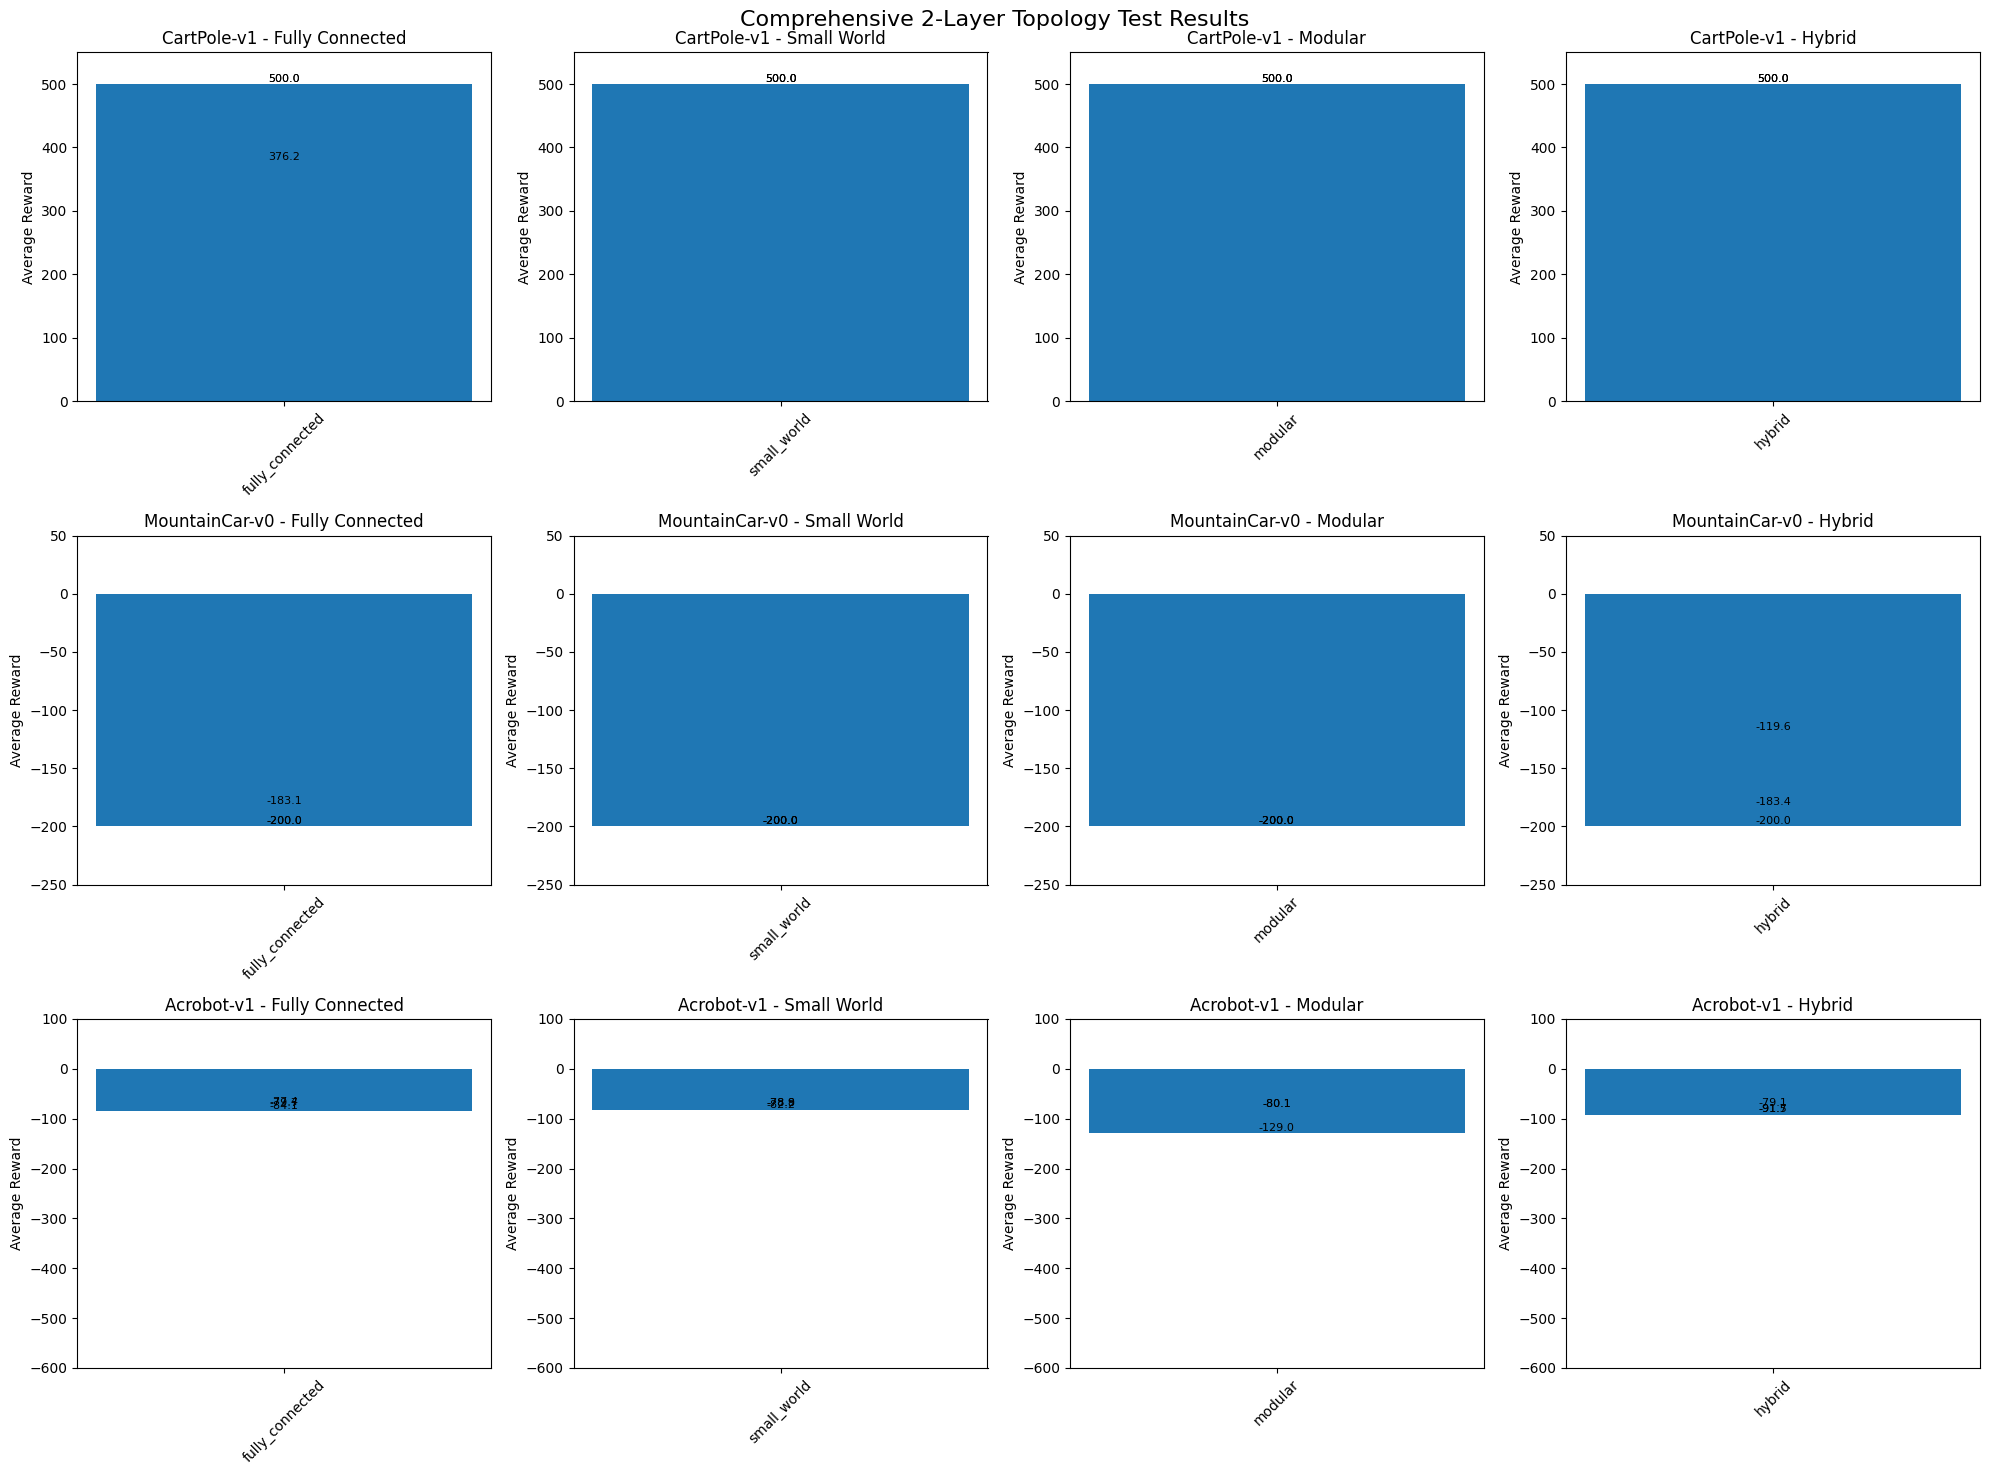


📊 COMPREHENSIVE 2-LAYER RESULTS SUMMARY

🎯 CARTPOLE-V1
--------------------------------------------------------------------------------
Topology        Version                   Avg Reward   Min      Max      Time(s) 
--------------------------------------------------------------------------------
Version C 2L    small_world               500.00       500      500      144.1   
Version C 2L    modular                   500.00       500      500      141.1   
Version C 2L    hybrid                    500.00       500      500      143.2   
Version C 2L    fully_connected           500.00       500      500      149.6   
Version B 2L    small_world               500.00       500      500      137.6   
Version B 2L    modular                   500.00       500      500      141.2   
Version B 2L    hybrid                    500.00       500      500      141.9   
Version B 2L    fully_connected           376.20       324      392      176.3   
Version A 2L    small_world               50

In [2]:
"""Run all experiments."""
print("🚀 Starting Comprehensive 2-Layer Topology Test")
print("=" * 80)
print("Testing: 4 topologies × 3 tasks × 4 versions = 48 experiments")
print("All using 2-layer topology networks")
print("=" * 80)

# Define all experiments
experiments = [
    # Standard MLP on all tasks
    (StandardMLPPolicy, "Standard MLP", "CartPole-v1"),
    (StandardMLPPolicy, "Standard MLP", "MountainCar-v0"),
    (StandardMLPPolicy, "Standard MLP", "Acrobot-v1"),
    
    # Version A (Adapters) on all topologies and tasks
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version A 2L - fully_connected", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version A 2L - small_world", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='modular', **kwargs), 
        "Version A 2L - modular", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version A 2L - hybrid", "CartPole-v1"),
    
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version A 2L - fully_connected", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version A 2L - small_world", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='modular', **kwargs), 
        "Version A 2L - modular", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version A 2L - hybrid", "MountainCar-v0"),
    
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version A 2L - fully_connected", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version A 2L - small_world", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='modular', **kwargs), 
        "Version A 2L - modular", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy_2Layers(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version A 2L - hybrid", "Acrobot-v1"),
    
    # Version B (Padding) on all topologies and tasks
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version B 2L - fully_connected", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version B 2L - small_world", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='modular', **kwargs), 
        "Version B 2L - modular", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version B 2L - hybrid", "CartPole-v1"),
    
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version B 2L - fully_connected", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version B 2L - small_world", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='modular', **kwargs), 
        "Version B 2L - modular", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version B 2L - hybrid", "MountainCar-v0"),
    
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version B 2L - fully_connected", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version B 2L - small_world", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='modular', **kwargs), 
        "Version B 2L - modular", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy_2Layers(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version B 2L - hybrid", "Acrobot-v1"),
    
    # Version C (Direct) on all topologies and tasks
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version C 2L - fully_connected", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version C 2L - small_world", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='modular', **kwargs), 
        "Version C 2L - modular", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version C 2L - hybrid", "CartPole-v1"),
    
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version C 2L - fully_connected", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version C 2L - small_world", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='modular', **kwargs), 
        "Version C 2L - modular", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version C 2L - hybrid", "MountainCar-v0"),
    
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version C 2L - fully_connected", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version C 2L - small_world", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='modular', **kwargs), 
        "Version C 2L - modular", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy_2Layers(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version C 2L - hybrid", "Acrobot-v1"),
]

# Run all experiments
results = []
for i, (policy_class, policy_name, env_name) in enumerate(experiments):
    print(f"\n🔄 Progress: {i+1}/{len(experiments)} ({((i+1)/len(experiments)*100):.1f}%)")
    try:
        result = test_policy(policy_class, policy_name, env_name)
        results.append(result)
    except Exception as e:
        print(f"❌ Error in {policy_name} on {env_name}: {e}")
        continue

# Create comprehensive visualization
plot_comprehensive_results(results)

# Create summary table
create_summary_table(results)

# Save results
import json
with open('comprehensive_topology_results_2layers.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✅ All experiments completed! {len(results)} successful runs.")
print("📁 Files created:")
print("  - comprehensive_topology_results_2layers.png (visualization)")
print("  - comprehensive_topology_results_2layers.json (raw data)")